# Automatic Game Balancing with Top Trumps

Install required packages:

In [ ]:
%pip install numpy pymoo

## Top Trumps Implementation

In [1]:
import random
import numpy as np

class TopTrumpsSimulation:
    """TopTrumpsSimulation implements the basic TopTrumps game engine and agent-based simulation."""

    def __init__(self, num_cards=52, num_categories=6):
        self.K = num_cards  # Number of cards
        self.L = num_categories  # Number of categories

        self.set_random_deck()

    def _normalize_deck(self, deck):
        """Normalizes the deck such that each property is in the range [0,1]. This is required for the p0 agent."""
        min_values = [0] * self.L
        max_values = [0] * self.L

        for cat in range(self.L):
            all_values = [card[cat] for card in deck]
            min_values[cat] = min(all_values)
            max_values[cat] = max(all_values)

        normalized_deck = []

        for card in deck:
            normalized_card = [0] * self.L
            for cat in range(self.L):
                normalized_card[cat] = (card[cat] - min_values[cat]) / (max_values[cat] - min_values[cat])
            normalized_deck.append(normalized_card)

        return normalized_deck

    def set_deck(self, deck_list):
        """Creates a deck from deck_list of length K*L."""

        assert len(deck_list) == self.K * self.L

        deck = np.array_split(deck_list, self.K)

        self.deck = deck
        self._normalized_deck = self._normalize_deck(deck)

    def set_random_deck(self, value_range = (1, 10)):
        """Generates a random deck with values in value_range."""
        deck_list = np.random.uniform(value_range[0], value_range[1], self.K * self.L)
        self.set_deck(deck_list)

    def get_p0_choice(self, card):
        """p0 assumes uniform distribution between max and min values per property and then picks the best value on current card."""
        return card.index(max(card))

    def get_p4_choice(self, card, remaining_cards):
        """p4 calculates exact win probability based on remaining cards."""
        best_prob = -1
        best_cat = 0

        for cat_idx in range(self.L):
            my_val = card[cat_idx]
            # Count how many cards in the potential card pool have a lower value
            wins = sum(1 for opp_card in remaining_cards if my_val > opp_card[cat_idx])
            prob = wins / len(remaining_cards)

            if prob > best_prob:
                best_prob = prob
                best_cat = cat_idx
        # print(f"Best prob: {best_prob:.2f}, cat: {best_cat}")
        return best_cat

    def simulate_game(self):
        # Shuffle and distribute cards
        temp_deck = list(self._normalized_deck)
        random.shuffle(temp_deck)

        # p4 vs p0 setup
        p4_hand = temp_deck[:self.K//2]
        p0_hand = temp_deck[self.K//2:]

        # Track unplayed cards remaining in the 'unplayed' pool for p4's knowledge 
        all_unplayed = list(temp_deck) 

        p4_tricks = 0
        current_turn = random.choice(['p4', 'p0']) # Random starting player
        trick_changes = 0

        # Game ends after all cards played once
        for i in range(self.K // 2):
            card_p4 = p4_hand[i]
            card_p0 = p0_hand[i]

            # Category Selection
            if current_turn == 'p4':
                category = self.get_p4_choice(card_p4, all_unplayed)
            else:
                category = self.get_p0_choice(card_p0)

            # Determine Round Winner
            val_p4 = card_p4[category]
            val_p0 = card_p0[category]

            # Remove current p0, p4 card from p4's tracking memory
            all_unplayed.remove(card_p0)
            all_unplayed.remove(card_p4)

            if val_p4 > val_p0:
                # print("P4 wins!")
                p4_tricks += 1
                if current_turn == 'p0':
                    current_turn = 'p4'
                    trick_changes += 1
            elif val_p0 > val_p4:
                # print("P0 wins!")
                if current_turn == 'p4':
                    current_turn = 'p0'
                    trick_changes += 1
            # In case of draw, current player keeps the lead

        return {
            "p4_tricks": p4_tricks,
            "trick_changes": trick_changes,
            "p4_won": p4_tricks > (self.K / 4) # p4 wins if they got more than half the tricks
        }

Test implementation on a random deck:

In [2]:
num_cards = 22
num_categories = 4
num_repetitions = 1000

sim = TopTrumpsSimulation(num_cards=num_cards, num_categories=num_categories)
sim.set_deck(np.random.uniform(0, 10, num_cards * num_categories))
results = [sim.simulate_game() for _ in range(num_repetitions)]

avg_p4_win_rate = sum(1 for r in results if r['p4_won']) / num_repetitions
avg_tricks = sum(r['p4_tricks'] for r in results) / num_repetitions
avg_trick_changes = sum(r['trick_changes'] for r in results) / num_repetitions

print(f"Results over {num_repetitions} runs:")
print(f"p4 Win Rate: {avg_p4_win_rate:.2%}")
print(f"Average p4 Tricks: {avg_tricks:.2f}")
print(f"Average Trick Changes: {avg_trick_changes:.2f}")

Results over 1000 runs:
p4 Win Rate: 54.80%
Average p4 Tricks: 5.86
Average Trick Changes: 1.83


## Pymoo connection

TopTrumpsBalancing provides a pymoo-compatible interface for TopTrumpsSimulation. Note that the objectives are already negated to result in a minimization problem!

In [3]:
import numpy as np
from pymoo.core.problem import ElementwiseProblem

class TopTrumpsBalancing(ElementwiseProblem):
    """TopTrumpsBalancing connects TopTrumpsSimulation with the pymoo interface ElementwiseProblem."""

    def __init__(self, sim_instance, n_simulations=100):
        self.sim = sim_instance
        self.n_simulations = n_simulations
        
        # KL variables: Number of cards (K) * Categories (L) 
        n_var = self.sim.K * self.sim.L
        
        super().__init__(n_var=n_var,
                         n_obj=2, # Objectives: Fairness (p4 win rate) and Excitement (# trick changes)
                         n_constr=0,
                         xl=1.0, # Lower bound for values
                         xu=10.0) # Upper bound for values

    def _evaluate(self, x, out, *args, **kwargs):
        # Update simulation with the current candidate deck
        self.sim.set_deck(x)
        
        win_rates = []
        trick_changes_list = []
        
        # Perform multiple simulations to get an average
        for _ in range(self.n_simulations):
            res = self.sim.simulate_game()
            win_rates.append(1 if res['p4_won'] else 0)
            trick_changes_list.append(res['trick_changes'])
        
        # Objectives (Minimization):
        # f1: -Average Win Rate of p4 (Fairness)
        # f2: -Average Trick Changes (Excitement)
        out["F"] = [
            -np.mean(win_rates), 
            -np.mean(trick_changes_list)
        ]

Set up simulation and problem instance:

In [ ]:
my_sim_k22_l4 = TopTrumpsSimulation(num_cards=22, num_categories=4)
my_sim_k22_l2 = TopTrumpsSimulation(num_cards=22, num_categories=2)
my_sim_k22_l6 = TopTrumpsSimulation(num_cards=22, num_categories=6)
problem_k22_l4 = TopTrumpsBalancing(my_sim_k22_l4, n_simulations=1000)
problem_k22_l2 = TopTrumpsBalancing(my_sim_k22_l2, n_simulations=1000)
problem_k22_l6 = TopTrumpsBalancing(my_sim_k22_l6, n_simulations=1000)


Now it's your turn: Optimize `problem` using an approach of your choice and analyze the results. Please refer to the documentation of [pymoo](https://pymoo.org) for more details. A good starting point is: <https://pymoo.org/getting_started/part_2.html#Initialize-an-Algorithm>

In [16]:
my_sim_k22_l1 = TopTrumpsSimulation(num_cards=22, num_categories=1)
problem_k22_l1 = TopTrumpsBalancing(my_sim_k22_l1, n_simulations=1000)

In [19]:
my_sim_k22_l10 = TopTrumpsSimulation(num_cards=22, num_categories=10)
problem_k22_l10 = TopTrumpsBalancing(my_sim_k22_l10, n_simulations=1000)

In [20]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.lhs import LHS
from pymoo.optimize import minimize
from pymoo.termination import get_termination

algorithm_k22_l10 = NSGA2(
    pop_size=100,  # Increased from 40
    n_offsprings=50,  # Increased from 10
    sampling=LHS(),  # Better initial distribution
    crossover=SBX(prob=0.9, eta=10),  # Lower eta for more exploration
    mutation=PM(eta=15, prob=1.0/problem_k22_l10.n_var),  # More explorative mutation
    eliminate_duplicates=True
)

termination = get_termination("n_gen", 150)  # More generations

res_k22_l10 = minimize(problem_k22_l10,
               algorithm_k22_l10,
               termination,
               seed=1,
               save_history=False,
               verbose=True)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      5 |             - |             -
     2 |      150 |      6 |  0.2500000000 |         ideal
     3 |      200 |      6 |  0.000000E+00 |             f
     4 |      250 |      5 |  0.0447761194 |         ideal
     5 |      300 |      6 |  0.3311148087 |         ideal
     6 |      350 |      2 |  0.3402061856 |         ideal
     7 |      400 |      2 |  0.000000E+00 |             f
     8 |      450 |      2 |  0.000000E+00 |             f
     9 |      500 |      3 |  0.1983471074 |         ideal
    10 |      550 |      3 |  0.000000E+00 |             f
    11 |      600 |      4 |  0.0470070712 |             f
    12 |      650 |      4 |  0.000000E+00 |             f
    13 |      700 |      4 |  0.000000E+00 |             f
    14 |      750 |      4 |  0.000000E+00 |             f
    15 |      800 |      4 |  0.1769547325 |         ideal
    16 |      850 |      4 |  0.000000E+00 |            

In [17]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.lhs import LHS
from pymoo.optimize import minimize
from pymoo.termination import get_termination

algorithm_k22_l1 = NSGA2(
    pop_size=100,  # Increased from 40
    n_offsprings=50,  # Increased from 10
    sampling=LHS(),  # Better initial distribution
    crossover=SBX(prob=0.9, eta=10),  # Lower eta for more exploration
    mutation=PM(eta=15, prob=1.0/problem_k22_l1.n_var),  # More explorative mutation
    eliminate_duplicates=True
)

termination = get_termination("n_gen", 150)  # More generations

res_k22_l1 = minimize(problem_k22_l1,
               algorithm_k22_l1,
               termination,
               seed=1,
               save_history=False,
               verbose=True)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      4 |             - |             -
     2 |      150 |      4 |  0.000000E+00 |             f
     3 |      200 |      4 |  0.000000E+00 |             f
     4 |      250 |      4 |  0.2857142857 |         ideal
     5 |      300 |      5 |  0.0272108844 |         ideal
     6 |      350 |      5 |  0.000000E+00 |             f
     7 |      400 |      6 |  0.0288640540 |             f
     8 |      450 |      6 |  0.000000E+00 |             f
     9 |      500 |      7 |  0.0981595092 |         ideal
    10 |      550 |      7 |  0.1641025641 |         ideal
    11 |      600 |      8 |  0.0231441688 |             f
    12 |      650 |      8 |  0.000000E+00 |             f
    13 |      700 |      8 |  0.1890243902 |         nadir
    14 |      750 |      8 |  0.000000E+00 |             f
    15 |      800 |      9 |  0.0224716415 |             f
    16 |      850 |      9 |  0.0050957450 |            

In [9]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.lhs import LHS
from pymoo.optimize import minimize
from pymoo.termination import get_termination

algorithm_k22_l4 = NSGA2(
    pop_size=100,  # Increased from 40
    n_offsprings=50,  # Increased from 10
    sampling=LHS(),  # Better initial distribution
    crossover=SBX(prob=0.9, eta=10),  # Lower eta for more exploration
    mutation=PM(eta=15, prob=1.0/problem_k22_l4.n_var),  # More explorative mutation
    eliminate_duplicates=True
)

termination = get_termination("n_gen", 150)  # More generations

res_k22_l4 = minimize(problem_k22_l4,
               algorithm_k22_l4,
               termination,
               seed=1,
               save_history=False,
               verbose=True)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      2 |             - |             -
     2 |      150 |      2 |  0.000000E+00 |             f
     3 |      200 |      3 |  0.6415094340 |         ideal
     4 |      250 |      3 |  0.000000E+00 |             f
     5 |      300 |      3 |  0.000000E+00 |             f
     6 |      350 |      3 |  0.000000E+00 |             f
     7 |      400 |      3 |  0.000000E+00 |             f
     8 |      450 |      3 |  0.000000E+00 |             f
     9 |      500 |      3 |  0.000000E+00 |             f
    10 |      550 |      3 |  0.000000E+00 |             f
    11 |      600 |      3 |  0.000000E+00 |             f
    12 |      650 |      3 |  0.000000E+00 |             f
    13 |      700 |      3 |  0.1239889327 |             f
    14 |      750 |      4 |  0.1114025983 |             f
    15 |      800 |      4 |  0.000000E+00 |             f
    16 |      850 |      4 |  0.2236421725 |         nad

In [11]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.lhs import LHS
from pymoo.optimize import minimize
from pymoo.termination import get_termination

algorithm_k22_l2 = NSGA2(
    pop_size=100,  # Increased from 40
    n_offsprings=50,  # Increased from 10
    sampling=LHS(),  # Better initial distribution
    crossover=SBX(prob=0.9, eta=10),  # Lower eta for more exploration
    mutation=PM(eta=15, prob=1.0/problem_k22_l2.n_var),  # More explorative mutation
    eliminate_duplicates=True
)

termination = get_termination("n_gen", 150)  # More generations

res_k22_l2 = minimize(problem_k22_l2,
               algorithm_k22_l2,
               termination,
               seed=1,
               save_history=False,
               verbose=True)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      2 |             - |             -
     2 |      150 |      4 |  0.1354359926 |         ideal
     3 |      200 |      4 |  0.1944444444 |         ideal
     4 |      250 |      5 |  0.0439571140 |             f
     5 |      300 |      5 |  0.2728785358 |         ideal
     6 |      350 |      6 |  0.0156734322 |             f
     7 |      400 |      9 |  0.0247424363 |             f
     8 |      450 |     10 |  0.2959183673 |         ideal
     9 |      500 |      6 |  0.2809457580 |         ideal
    10 |      550 |      6 |  0.000000E+00 |             f
    11 |      600 |      5 |  0.1136718825 |             f
    12 |      650 |      7 |  0.0573561359 |             f
    13 |      700 |      4 |  0.0337837838 |         ideal
    14 |      750 |      5 |  0.2291666667 |         ideal
    15 |      800 |      6 |  0.0335195531 |         ideal
    16 |      850 |      6 |  0.0182147374 |            

In [13]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.lhs import LHS
from pymoo.optimize import minimize
from pymoo.termination import get_termination

algorithm_k22_l6 = NSGA2(
    pop_size=100,  # Increased from 40
    n_offsprings=50,  # Increased from 10
    sampling=LHS(),  # Better initial distribution
    crossover=SBX(prob=0.9, eta=10),  # Lower eta for more exploration
    mutation=PM(eta=15, prob=1.0/problem_k22_l6.n_var),  # More explorative mutation
    eliminate_duplicates=True
)

termination = get_termination("n_gen", 150)  # More generations

res_k22_l6 = minimize(problem_k22_l6,
               algorithm_k22_l6,
               termination,
               seed=1,
               save_history=False,
               verbose=True)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      2 |             - |             -
     2 |      150 |      3 |  0.8769230769 |         ideal
     3 |      200 |      2 |  0.0527306968 |         ideal
     4 |      250 |      2 |  0.000000E+00 |             f
     5 |      300 |      2 |  0.000000E+00 |             f
     6 |      350 |      4 |  0.1930091185 |         ideal
     7 |      400 |      3 |  0.0193740686 |         ideal
     8 |      450 |      3 |  0.000000E+00 |             f
     9 |      500 |      3 |  0.000000E+00 |             f
    10 |      550 |      5 |  0.2030878860 |         ideal
    11 |      600 |      6 |  0.0472000716 |             f
    12 |      650 |      7 |  0.1663366337 |         ideal
    13 |      700 |      7 |  0.0108344515 |             f
    14 |      750 |      8 |  0.0078809135 |             f
    15 |      800 |      9 |  0.0053922164 |             f
    16 |      850 |     10 |  0.0248475790 |            

/tmp/ipykernel_347129/2806172400.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_list))


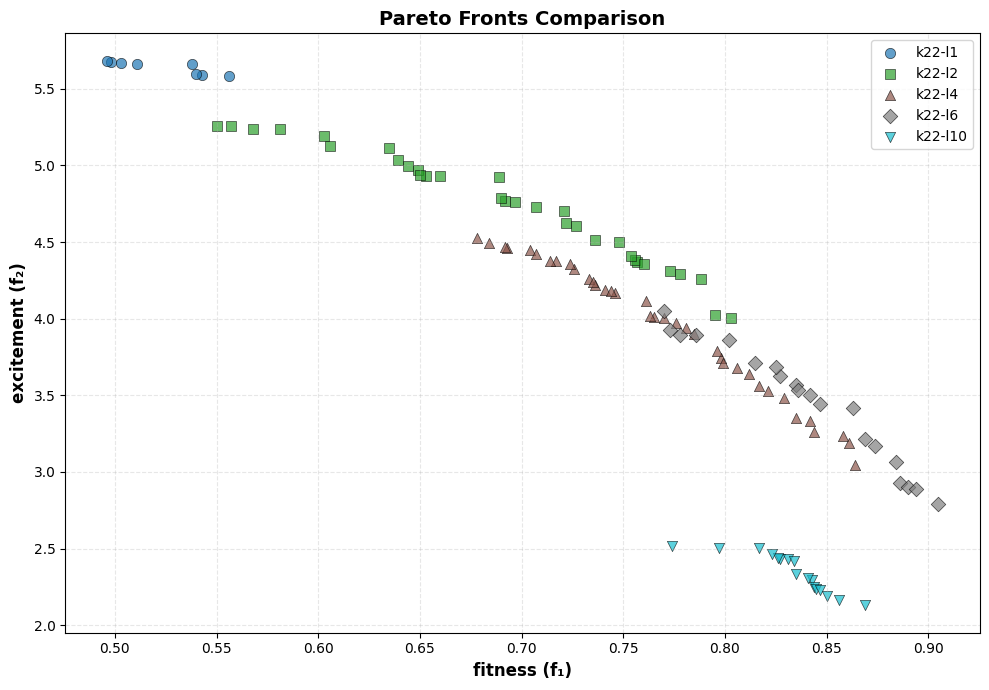

In [23]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pareto_list(results_list, labels=None, title='Pareto Fronts Comparison'):
    """
    Plots multiple Pareto fronts from a list of result objects.
    
    Parameters:
    - results_list: List of result objects (each must have a .F attribute)
    - labels: Optional list of strings. If None, uses 'Result 1, 2...' 
    - title: String for the plot title
    """
    plt.figure(figsize=(10, 7))
    
    # Setup color cycle and markers
    colors = plt.cm.get_cmap('tab10', len(results_list))
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

    for i, res in enumerate(results_list):
        # Determine label: use provided labels, object attribute, or default index
        if labels and i < len(labels):
            current_label = labels[i]
        else:
            current_label = getattr(res, 'label', f'Result {i+1}')
        
        # Plotting the F objective values
        plt.scatter(-res.F[:, 0], -res.F[:, 1], 
                    c=[colors(i)], 
                    marker=markers[i % len(markers)], 
                    s=55, alpha=0.7, 
                    label=current_label, 
                    edgecolors='black', linewidth=0.5)

    # Formatting
    plt.xlabel('fitness (f₁)', fontsize=12, fontweight='bold')
    plt.ylabel('excitement (f₂)', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(loc='best', fontsize=10, framealpha=0.8)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    plt.show()

# --- Usage Example ---
# my_results = [res_k22_l2, res_k22_l4, res_k22_l6, res_k22_l8]
# my_labels = ['k22-l2', 'k22-l4', 'k22-l6', 'k22-l8']
# plot_pareto_list(my_results, labels=my_labels)
plot_pareto_list([res_k22_l1, res_k22_l2, res_k22_l4, res_k22_l6, res_k22_l10], ['k22-l1', 'k22-l2', 'k22-l4', 'k22-l6', 'k22-l10'])

/tmp/ipykernel_347129/2806172400.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_list))


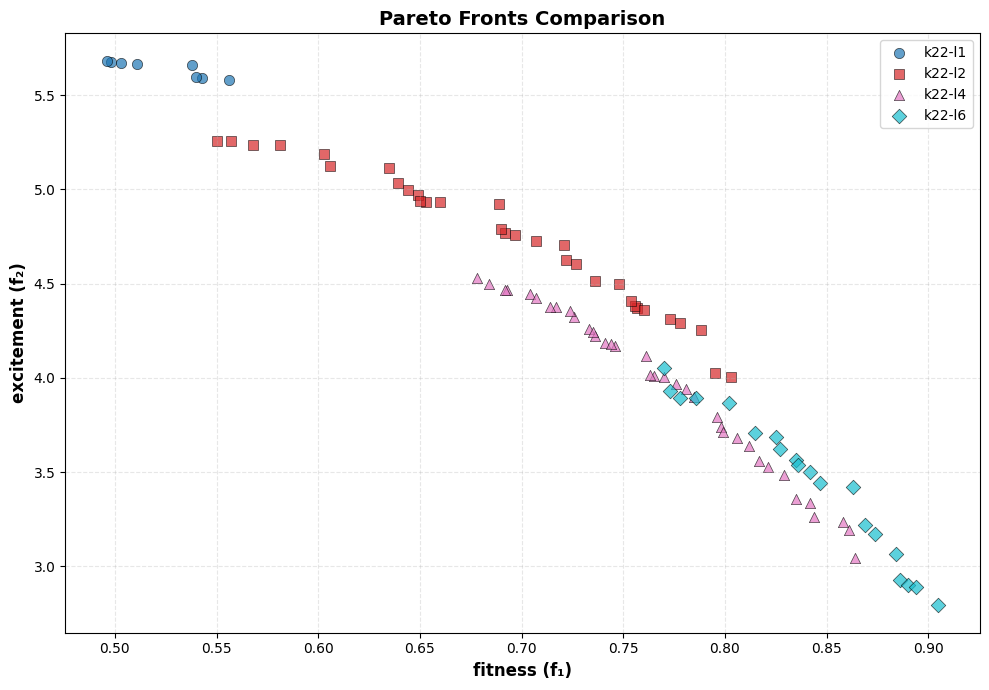

In [24]:
plot_pareto_list([res_k22_l1, res_k22_l2, res_k22_l4, res_k22_l6], ['k22-l1', 'k22-l2', 'k22-l4', 'k22-l6'])

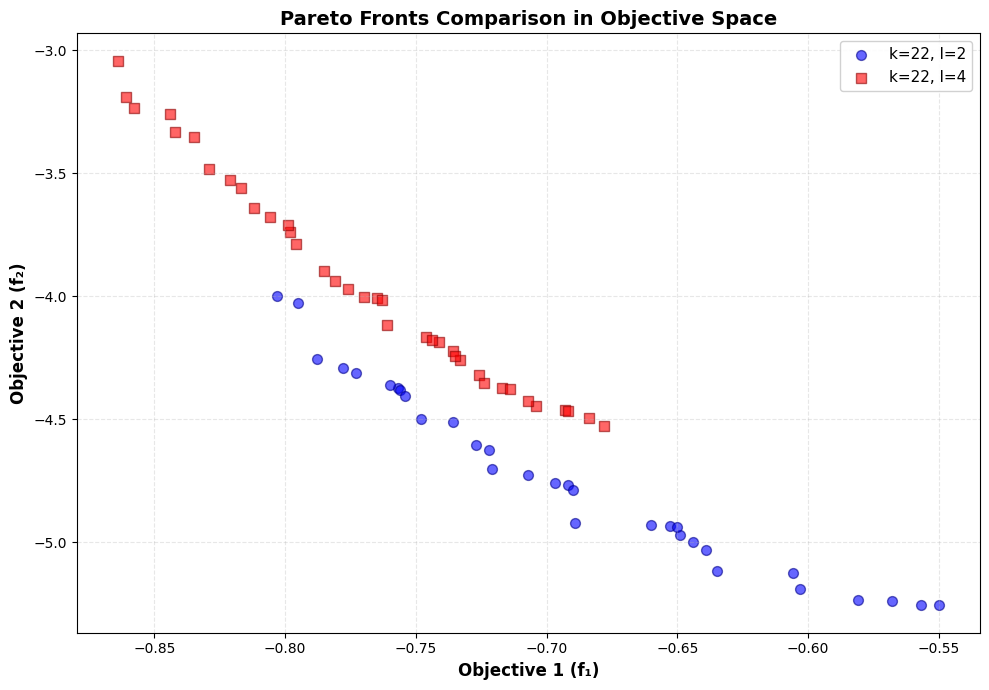


Pareto Front Statistics:
L=2 Configuration:
  Number of solutions: 32
  f₁ range: [-0.8030, -0.5500]
  f₂ range: [-5.2580, -4.0020]

L=4 Configuration:
  Number of solutions: 37
  f₁ range: [-0.8640, -0.6780]
  f₂ range: [-4.5280, -3.0430]


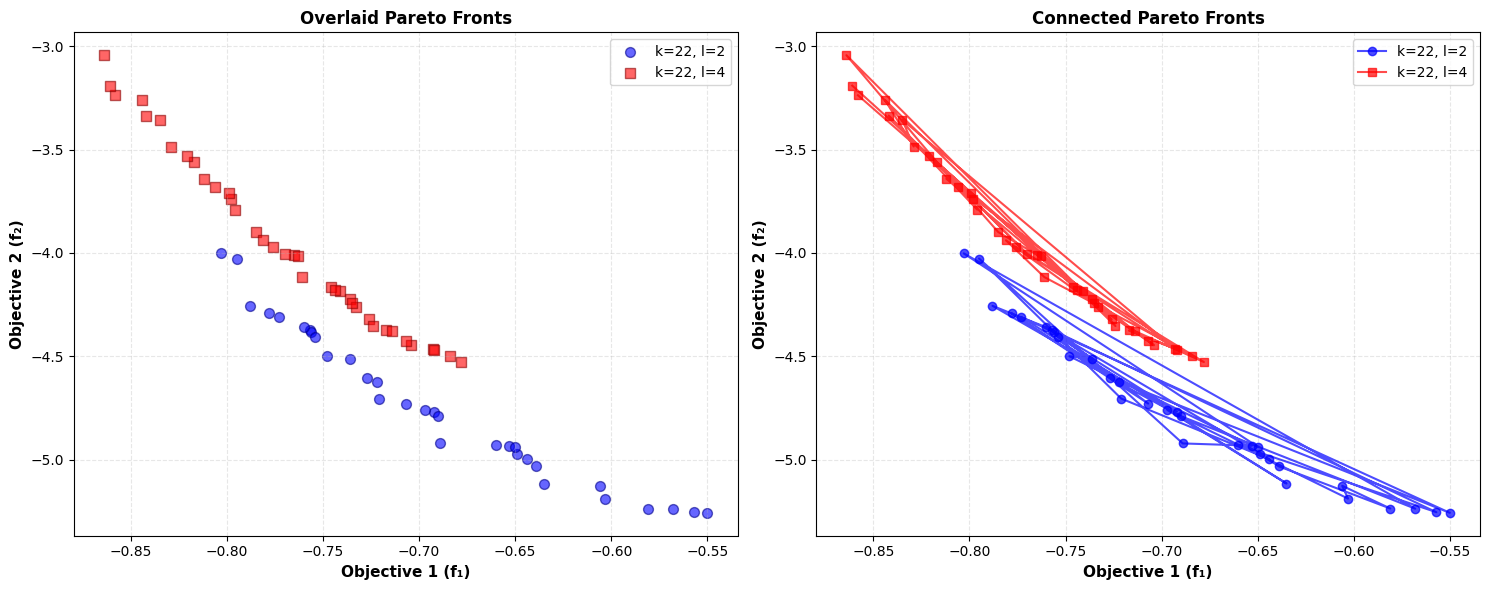

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Extract the objective values from the results
# res.F contains the objective values for all solutions in the Pareto front
F_l2 = res_k22_l2.F
F_l4 = res_k22_l4.F

# Create the plot
plt.figure(figsize=(10, 7))

# Plot both Pareto fronts
plt.scatter(F_l2[:, 0], F_l2[:, 1], 
           c='blue', marker='o', s=50, alpha=0.6, 
           label='k=22, l=2', edgecolors='darkblue', linewidth=1)

plt.scatter(F_l4[:, 0], F_l4[:, 1], 
           c='red', marker='s', s=50, alpha=0.6, 
           label='k=22, l=4', edgecolors='darkred', linewidth=1)

# Add labels and title
plt.xlabel('Objective 1 (f₁)', fontsize=12, fontweight='bold')
plt.ylabel('Objective 2 (f₂)', fontsize=12, fontweight='bold')
plt.title('Pareto Fronts Comparison in Objective Space', fontsize=14, fontweight='bold')

# Add legend
plt.legend(loc='best', fontsize=11, framealpha=0.9)

# Add grid for better readability
plt.grid(True, alpha=0.3, linestyle='--')

# Tight layout for better spacing
plt.tight_layout()

# Display the plot
plt.show()

# Optional: Print some statistics
print(f"\nPareto Front Statistics:")
print(f"{'='*50}")
print(f"L=2 Configuration:")
print(f"  Number of solutions: {len(F_l2)}")
print(f"  f₁ range: [{F_l2[:, 0].min():.4f}, {F_l2[:, 0].max():.4f}]")
print(f"  f₂ range: [{F_l2[:, 1].min():.4f}, {F_l2[:, 1].max():.4f}]")

print(f"\nL=4 Configuration:")
print(f"  Number of solutions: {len(F_l4)}")
print(f"  f₁ range: [{F_l4[:, 0].min():.4f}, {F_l4[:, 0].max():.4f}]")
print(f"  f₂ range: [{F_l4[:, 1].min():.4f}, {F_l4[:, 1].max():.4f}]")
print(f"{'='*50}")

# Optional: Create a more detailed comparison plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left plot: Both fronts overlaid
axes[0].scatter(F_l2[:, 0], F_l2[:, 1], 
               c='blue', marker='o', s=50, alpha=0.6, 
               label='k=22, l=2', edgecolors='darkblue', linewidth=1)
axes[0].scatter(F_l4[:, 0], F_l4[:, 1], 
               c='red', marker='s', s=50, alpha=0.6, 
               label='k=22, l=4', edgecolors='darkred', linewidth=1)
axes[0].set_xlabel('Objective 1 (f₁)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Objective 2 (f₂)', fontsize=11, fontweight='bold')
axes[0].set_title('Overlaid Pareto Fronts', fontsize=12, fontweight='bold')
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(True, alpha=0.3, linestyle='--')

# Right plot: Individual fronts side by side
axes[1].plot(F_l2[:, 0], F_l2[:, 1], 
            'o-', color='blue', markersize=6, alpha=0.7, 
            label='k=22, l=2', linewidth=1.5)
axes[1].plot(F_l4[:, 0], F_l4[:, 1], 
            's-', color='red', markersize=6, alpha=0.7, 
            label='k=22, l=4', linewidth=1.5)
axes[1].set_xlabel('Objective 1 (f₁)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Objective 2 (f₂)', fontsize=11, fontweight='bold')
axes[1].set_title('Connected Pareto Fronts', fontsize=12, fontweight='bold')
axes[1].legend(loc='best', fontsize=10)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [25]:
#my_sim_k22_l4 = TopTrumpsSimulation(num_cards=22, num_categories=4)
#problem_k22_l4 = TopTrumpsBalancing(my_sim_k22_l4, n_simulations=1000)
my_sim_k15_l4 = TopTrumpsSimulation(num_cards=15, num_categories=4)
problem_k15_l4 = TopTrumpsBalancing(my_sim_k15_l4, n_simulations=1000)
my_sim_k29_l4 = TopTrumpsSimulation(num_cards=29, num_categories=4)
problem_k29_l4 = TopTrumpsBalancing(my_sim_k29_l4, n_simulations=1000)

In [26]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.lhs import LHS
from pymoo.optimize import minimize
from pymoo.termination import get_termination

algorithm_k15_l4 = NSGA2(
    pop_size=100,  # Increased from 40
    n_offsprings=50,  # Increased from 10
    sampling=LHS(),  # Better initial distribution
    crossover=SBX(prob=0.9, eta=10),  # Lower eta for more exploration
    mutation=PM(eta=15, prob=1.0/problem_k15_l4.n_var),  # More explorative mutation
    eliminate_duplicates=True
)

termination = get_termination("n_gen", 150)  # More generations

res_k15_l4 = minimize(problem_k15_l4,
               algorithm_k15_l4,
               termination,
               seed=1,
               save_history=False,
               verbose=True)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      3 |             - |             -
     2 |      150 |      5 |  0.2334004024 |         ideal
     3 |      200 |      7 |  0.0579796252 |             f
     4 |      250 |      6 |  0.1951219512 |         ideal
     5 |      300 |      6 |  0.2971576227 |         ideal
     6 |      350 |      5 |  0.0124031008 |             f
     7 |      400 |      4 |  0.0936768150 |         ideal
     8 |      450 |      5 |  0.0249647304 |             f
     9 |      500 |      4 |  0.1294736842 |         ideal
    10 |      550 |      4 |  0.000000E+00 |             f
    11 |      600 |      4 |  0.000000E+00 |             f
    12 |      650 |      5 |  0.0256410256 |         ideal
    13 |      700 |      6 |  0.0071944874 |             f
    14 |      750 |      6 |  0.0927152318 |         ideal
    15 |      800 |      6 |  0.000000E+00 |             f
    16 |      850 |      5 |  0.0488790461 |            

In [28]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.lhs import LHS
from pymoo.optimize import minimize
from pymoo.termination import get_termination

algorithm_k29_l4 = NSGA2(
    pop_size=100,  # Increased from 40
    n_offsprings=50,  # Increased from 10
    sampling=LHS(),  # Better initial distribution
    crossover=SBX(prob=0.9, eta=10),  # Lower eta for more exploration
    mutation=PM(eta=15, prob=1.0/problem_k29_l4.n_var),  # More explorative mutation
    eliminate_duplicates=True
)

termination = get_termination("n_gen", 150)  # More generations

res_k29_l4 = minimize(problem_k29_l4,
               algorithm_k29_l4,
               termination,
               seed=1,
               save_history=False,
               verbose=True)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      4 |             - |             -
     2 |      150 |      5 |  0.0362358801 |             f
     3 |      200 |      7 |  0.0213836478 |         ideal
     4 |      250 |     10 |  0.1488222698 |         ideal
     5 |      300 |     11 |  0.0299836664 |             f
     6 |      350 |     11 |  0.000000E+00 |             f
     7 |      400 |     11 |  0.0225055280 |             f
     8 |      450 |     10 |  0.0260688217 |         ideal
     9 |      500 |     12 |  0.2941176471 |         ideal
    10 |      550 |     11 |  0.0657276995 |         ideal
    11 |      600 |      5 |  0.0431266846 |         ideal
    12 |      650 |      5 |  0.000000E+00 |             f
    13 |      700 |      5 |  0.0188044578 |             f
    14 |      750 |      7 |  0.0480906182 |             f
    15 |      800 |      8 |  0.0264332410 |             f
    16 |      850 |      8 |  0.000000E+00 |            

/tmp/ipykernel_347129/2806172400.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_list))


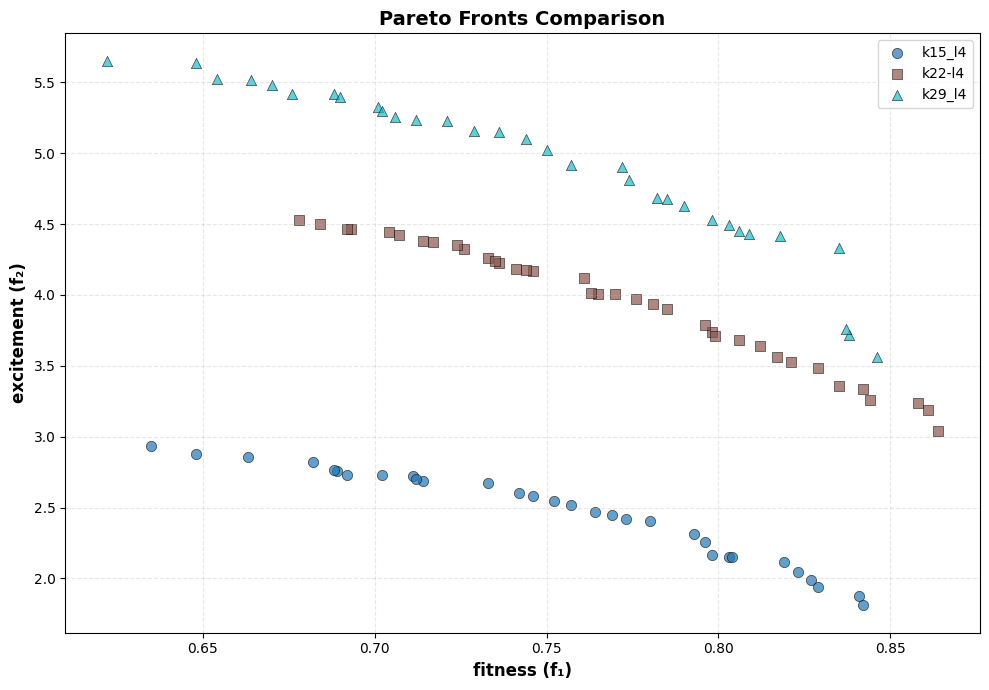

In [29]:
plot_pareto_list([res_k15_l4, res_k22_l4, res_k29_l4], ['k15_l4', 'k22-l4', 'k29_l4'])